# Exploratory Data Analysis with Pyspark and Spark SQL

The following notebook utilizes New York City taxi data from [TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

## Instructions

- Load and explore nyc taxi data from january 0f 2019. The exercises can be executed using pyspark or spark sql (a subset of the questions will be re-answered using the language not chosen for the  main work).
- Load the zone lookup table to answer the questions about the nyc boroughs.  
- Load nyc taxi data from January of 2025 and compare data.  
- With any remaining time, work on the where to go from here section.
- Note: the initial lab is opened as read only. To save work completed utilize the `save notebook as` option and give the lab a new name.

In [1]:
import requests

# start a spark session and create a spark context
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("nyc_taxi") \
    .getOrCreate()

sc = spark.sparkContext

In [2]:
# set dl url for January 2019 trip data
download_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-01.parquet'

# get the data
response = requests.get(download_url)

# check that response was good and save the data
jan_2019_trip_data = "yellow_tripdata_2019-01.parquet"
if response.status_code == 200:
    # Changed 'response' to 'data' here
    with open(jan_2019_trip_data, "wb") as f:
        f.write(response.content)


In [3]:
# create the dataframe
df_trips = spark.read.parquet(jan_2019_trip_data)

# A brief note on handling data sources in spark

The command above works well for loading data from parquet files because parquet is a self descibing file format, meaning that the metadata needed to build the dataframe is included directly in the format. However, when working with other formats such as csv or json, a schema must be provided or infered. In production code the schema should always be explicitly provided but during the data exploration phase it is acceptable to infer the schema, and when infering the schema it often best to use `.option("samplingRatio", <small-portion-of-data>)` to avoid using the entire dataset for schema inference.

```python
df_trips = spark.read.format("csv") \
    .option("header", "true") \
    .option("sep", ",") \
    .option("samplingRatio", 0.01) \
    .load("large_dataset.csv")
```

In [4]:
# Show the dataframe
df_trips.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2019-01-01 00:46:40|  2019-01-01 00:53:20|            1.0|          1.5|       1.0|                 N|         151|         239|           1|        7.0|  0.5|    0.5|      1.6

In [5]:
from pyspark.sql import functions as F, Window
from pyspark.sql.types import IntegerType, StringType, StructField, StructType

## Lab

### Part 1
This section can be completed either using pyspark commands or sql commands ( There will be a section after in which a self-chosen subset of the questions are re-answered using the language not used for the main section. i.e. if pyspark is chosen for the main lab, sql should be used to repeat some of the questions. )

- Add a column that creates a unique key to identify each record in order to answer questions about individual trips
- Which trip has the highest passanger count
- What is the Average passanger count
- Shortest/longest trip by distance? by time?.
- busiest day/slowest single day
- busiest/slowest time of day ( you may want to bucket these by hour or create timess such as morning, afternoon, evening, late night )
- On average which day of the week is slowest/busiest
- Does trip distance or num passangers affect tip amount
- What was the highest "extra" charge and which trip
- Are there any datapoints that seem to be strange/outliers (make sure to explain your reasoning in a markdown cell)?

**Unique key and duration.** `monotonically_increasing_id()` gives every row a unique 64-bit id: there are 7,696,617 rows and 7,696,617 distinct ids. The ids are not consecutive (Spark puts the partition number in the high bits) but they are unique, which is all a key needs. I also add `duration_min`, because several questions need the trip time. Even in these first rows we can see dirty data: two pickups are in 2018 and some trips have a distance of 0.

In [6]:
# Part 1 is done with PySpark; Part 3 redoes three questions in SQL.
# 1. a unique key for every trip + the trip duration in minutes
df = (df_trips
      .withColumn("trip_id", F.monotonically_increasing_id())
      .withColumn("duration_min",
                  (F.unix_timestamp("tpep_dropoff_datetime")
                   - F.unix_timestamp("tpep_pickup_datetime")) / 60))

print("rows:", df.count(), "| distinct trip_id:",
      df.select("trip_id").distinct().count())
df.select("trip_id", "tpep_pickup_datetime", "trip_distance",
          "duration_min", "total_amount").show(5)

rows: 7696617 | distinct trip_id: 7696617


+-----------+--------------------+-------------+------------------+------------+
|    trip_id|tpep_pickup_datetime|trip_distance|      duration_min|total_amount|
+-----------+--------------------+-------------+------------------+------------+
|25769803776| 2019-01-01 00:46:40|          1.5| 6.666666666666667|        9.95|
|25769803777| 2019-01-01 00:59:47|          2.6|              19.2|        16.3|
|25769803778| 2018-12-21 13:48:30|          0.0| 4.166666666666667|         5.8|
|25769803779| 2018-11-28 15:52:25|          0.0|3.3333333333333335|        7.55|
|25769803780| 2018-11-28 15:56:57|          0.0|               1.6|       55.55|
+-----------+--------------------+-------------+------------------+------------+
only showing top 5 rows


**Keeping real January trips.** The file is supposed to be January 2019, but 537 rows have a pickup date outside the month (441 before 2019 and 96 after January 2019) and 4 trips end before they start. Any question about days or hours would be wrong with them, so `df_jan` keeps only the January 2019 trips with a duration >= 0: 7,696,076 trips (541 rows removed). The full outlier analysis is at the end of Part 1.

In [7]:
# The raw file contains pickups outside January 2019 and trips that end
# before they start (see the outlier question at the end of Part 1).
# For every question about time we only keep real January 2019 trips.
df_jan = df.filter(
    (F.col("tpep_pickup_datetime") >= "2019-01-01")
    & (F.col("tpep_pickup_datetime") < "2019-02-01")
    & (F.col("duration_min") >= 0))

print("raw trips:", df.count(), "| January 2019 trips:", df_jan.count())

raw trips: 7696617 | January 2019 trips: 7696076


**Highest passenger count.** The maximum is 9 passengers and 9 trips share it, so there is no single winner (the first one by id is `25770753732`). All the trips shown have a distance of 0, and 9 people cannot fit in a yellow cab, so this looks like an input error by the driver rather than a real trip.

In [8]:
# Which trip has the highest passenger count?
max_pax = df.agg(F.max("passenger_count")).first()[0]
print("max passenger count:", max_pax,
      "| trips with that count:", df.filter(F.col("passenger_count") == max_pax).count())
(df.filter(F.col("passenger_count") == max_pax)
   .select("trip_id", "tpep_pickup_datetime", "passenger_count",
           "trip_distance", "total_amount")
   .orderBy("trip_id").show(5))

max passenger count: 9.0 | trips with that count: 9


+-----------+--------------------+---------------+-------------+------------+
|    trip_id|tpep_pickup_datetime|passenger_count|trip_distance|total_amount|
+-----------+--------------------+---------------+-------------+------------+
|25770753732| 2019-01-05 13:12:29|            9.0|          0.0|        12.6|
|25771100063| 2019-01-07 03:19:36|            9.0|          0.0|         9.3|
|25771815874| 2019-01-10 00:43:10|            9.0|          0.0|        11.3|
|25772687771| 2019-01-13 04:13:24|            9.0|          0.0|       12.25|
|25774338483| 2019-01-19 16:45:25|            9.0|          0.0|      110.76|
+-----------+--------------------+---------------+-------------+------------+
only showing top 5 rows


**Average passenger count.** The average is 1.567 passengers per trip (1.591 if we ignore the trips with 0 passengers). 117,381 trips have 0 passengers and 28,672 have no value at all (NULL, ignored by `avg`); these are probably trips where the driver did not fill in the field. The distribution shows that the typical taxi ride is a single person: 5,456,515 trips, about 71% of the dataset.

In [9]:
# What is the average passenger count?
df.agg(
    F.round(F.avg("passenger_count"), 3).alias("avg_all_trips"),
    F.round(F.avg(F.when(F.col("passenger_count") > 0,
                         F.col("passenger_count"))), 3).alias("avg_without_zero"),
    F.sum((F.col("passenger_count") == 0).cast("int")).alias("trips_with_0_passenger"),
).show()
df.groupBy("passenger_count").count().orderBy("passenger_count").show()

+-------------+----------------+----------------------+
|avg_all_trips|avg_without_zero|trips_with_0_passenger|
+-------------+----------------+----------------------+
|        1.567|           1.591|                117381|
+-------------+----------------+----------------------+



+---------------+-------+
|passenger_count|  count|
+---------------+-------+
|           NULL|  28672|
|            0.0| 117381|
|            1.0|5456515|
|            2.0|1113894|
|            3.0| 314692|
|            4.0| 140753|
|            5.0| 323842|
|            6.0| 200811|
|            7.0|     19|
|            8.0|     29|
|            9.0|      9|
+---------------+-------+



**Shortest / longest by distance.** 55,089 trips have a distance of exactly 0, so I look at the shortest *positive* distance: 0.01 miles (about 16 meters) with a duration of less than a minute; one of them even has a negative fare (-2.5), which looks like a refund or a correction. The longest trip is 831.8 miles in 9.5 minutes, which is impossible (about 5,000 mph), and the second one has the same problem (700.7 miles in 6.9 minutes). The next ones (214, 211 and 201 miles, with fares between 50 and 760 dollars and durations between 3 and 11 hours) are believable long-distance trips.

In [10]:
# Shortest / longest trip by distance
print("trips with a distance of exactly 0:",
      df.filter(F.col("trip_distance") == 0).count())
cols = ["trip_id", "tpep_pickup_datetime", "trip_distance", "duration_min",
        "fare_amount", "total_amount"]
print("shortest positive distances")
df.filter(F.col("trip_distance") > 0).orderBy("trip_distance").select(cols).show(3)
print("longest distances")
df.orderBy(F.desc("trip_distance")).select(cols).show(5)

trips with a distance of exactly 0: 55089
shortest positive distances


+-----------+--------------------+-------------+-------------------+-----------+------------+
|    trip_id|tpep_pickup_datetime|trip_distance|       duration_min|fare_amount|total_amount|
+-----------+--------------------+-------------+-------------------+-----------+------------+
|25769816340| 2019-01-01 00:02:54|         0.01|0.06666666666666667|        2.5|         3.8|
|25769822604| 2019-01-01 01:03:20|         0.01| 0.6833333333333333|       -2.5|        -3.8|
|25769818095| 2019-01-01 01:34:48|         0.01| 0.4666666666666667|        2.5|         3.8|
+-----------+--------------------+-------------+-------------------+-----------+------------+
only showing top 3 rows
longest distances


+-----------+--------------------+-------------+------------------+-----------+------------+
|    trip_id|tpep_pickup_datetime|trip_distance|      duration_min|fare_amount|total_amount|
+-----------+--------------------+-------------+------------------+-----------+------------+
|25775877867| 2019-01-25 21:56:39|        831.8| 9.483333333333333|        8.5|       11.76|
|25774090409| 2019-01-18 16:32:24|        700.7| 6.933333333333334|        6.0|         9.0|
|25776574761| 2019-01-28 17:24:11|       214.01| 673.0833333333334|      760.0|       761.8|
|25774511310| 2019-01-20 12:22:24|       211.36|             283.2|       50.0|       56.56|
|25774685561| 2019-01-21 10:13:05|       201.27|194.93333333333334|      150.0|      152.46|
+-----------+--------------------+-------------+------------------+-----------+------------+
only showing top 5 rows


**Shortest / longest by duration.** 6,550 trips last 0 minutes. The shortest positive duration is 1 second, and one of these has a total of 65.88 dollars for a distance of 0, so the meter or the timestamps are wrong. The longest "trips" last 43,648 minutes (30 days!), 33,857 minutes (23.5 days) and 31,532 minutes (22 days) for distances of 1 to 4 miles: the meter was clearly left running or the dropoff time is wrong. Even the 5th longest lasts 1,687 minutes (28 hours), which is not realistic either.

In [11]:
# Shortest / longest trip by duration (January 2019 trips only)
print("trips with a duration of 0 minutes:",
      df_jan.filter(F.col("duration_min") == 0).count())
cols = ["trip_id", "tpep_pickup_datetime", "duration_min", "trip_distance",
        "total_amount"]
print("shortest positive durations")
df_jan.filter(F.col("duration_min") > 0).orderBy("duration_min").select(cols).show(3)
print("longest durations")
df_jan.orderBy(F.desc("duration_min")).select(cols).show(5)

trips with a duration of 0 minutes: 6550
shortest positive durations


+-----------+--------------------+--------------------+-------------+------------+
|    trip_id|tpep_pickup_datetime|        duration_min|trip_distance|total_amount|
+-----------+--------------------+--------------------+-------------+------------+
|25769826269| 2019-01-01 01:46:23|0.016666666666666666|          0.0|       65.88|
|25769837295| 2019-01-01 02:18:39|0.016666666666666666|          0.0|         3.8|
|25769827127| 2019-01-01 01:09:17|0.016666666666666666|          0.0|       71.76|
+-----------+--------------------+--------------------+-------------+------------+
only showing top 3 rows
longest durations


+-----------+--------------------+------------------+-------------+------------+
|    trip_id|tpep_pickup_datetime|      duration_min|trip_distance|total_amount|
+-----------+--------------------+------------------+-------------+------------+
|25769872043| 2019-01-01 07:01:20| 43648.01666666667|          1.2|         7.3|
|25770396038| 2019-01-03 22:24:36|33856.683333333334|          1.1|       11.15|
|25770679632| 2019-01-05 04:21:40|           31532.1|          3.9|       21.35|
|25773519501| 2019-01-16 15:31:14|            7190.9|          0.0|      1079.4|
|25771519041| 2019-01-08 20:18:52|1687.0333333333333|         0.78|         6.8|
+-----------+--------------------+------------------+-------------+------------+
only showing top 5 rows


**Busiest / slowest day.** The two busiest days are Fridays: January 25 (292,499 trips) and January 11 (291,714 trips), followed by Thursdays. The slowest days are January 1 (189,432 trips, New Year's Day) and January 21 (192,826 trips, which was Martin Luther King Jr. Day, a holiday), then January 2. So the extremes are explained by the calendar: end-of-week days for the peaks, holidays for the lows.

In [12]:
# Busiest / slowest single day
daily = (df_jan
         .groupBy(F.to_date("tpep_pickup_datetime").alias("day"))
         .count()
         .withColumn("weekday", F.date_format("day", "EEEE")))
print("busiest days")
daily.orderBy(F.desc("count")).show(5)
print("slowest days")
daily.orderBy("count").show(5)

busiest days


+----------+------+--------+
|       day| count| weekday|
+----------+------+--------+
|2019-01-25|292499|  Friday|
|2019-01-11|291714|  Friday|
|2019-01-31|284625|Thursday|
|2019-01-17|284580|Thursday|
|2019-01-24|281959|Thursday|
+----------+------+--------+
only showing top 5 rows
slowest days


+----------+------+---------+
|       day| count|  weekday|
+----------+------+---------+
|2019-01-01|189432|  Tuesday|
|2019-01-21|192826|   Monday|
|2019-01-02|198737|Wednesday|
|2019-01-20|203113|   Sunday|
|2019-01-06|208822|   Sunday|
+----------+------+---------+
only showing top 5 rows


**Busiest / slowest time of day.** The slowest hour is 4 am (61,423 trips). The activity then grows from 6 am, stays around 360,000-375,000 trips per hour during the morning, and grows again in the afternoon to reach the peak at 6 pm (515,374 trips, evening rush hour). After 9 pm it decreases. In the buckets, the evening (17-21h) is the busiest period with 2.29M trips and the late night (22-4h) the slowest with 1.26M. The buckets do not have the same length (the late night has 7 hours and the evening 5), so the gap per hour is even bigger than it looks.

In [13]:
# Busiest / slowest time of day: by hour, then by period of the day
hourly = (df_jan.groupBy(F.hour("tpep_pickup_datetime").alias("hour"))
                .count().orderBy("hour"))
hourly.show(24)

periods = (df_jan
           .withColumn("hour", F.hour("tpep_pickup_datetime"))
           .withColumn("period",
                       F.when(F.col("hour").between(5, 11), "morning (5-11h)")
                        .when(F.col("hour").between(12, 16), "afternoon (12-16h)")
                        .when(F.col("hour").between(17, 21), "evening (17-21h)")
                        .otherwise("late night (22-4h)"))
           .groupBy("period").count().orderBy(F.desc("count")))
periods.show(truncate=False)

+----+------+
|hour| count|
+----+------+
|   0|207758|
|   1|149242|
|   2|109413|
|   3| 78084|
|   4| 61423|
|   5| 75532|
|   6|178598|
|   7|304858|
|   8|373735|
|   9|365924|
|  10|361382|
|  11|375438|
|  12|401172|
|  13|404149|
|  14|433115|
|  15|452676|
|  16|420805|
|  17|468407|
|  18|515374|
|  19|475152|
|  20|423128|
|  21|409873|
|  22|369026|
|  23|281812|
+----+------+



+------------------+-------+
|period            |count  |
+------------------+-------+
|evening (17-21h)  |2291934|
|afternoon (12-16h)|2111917|
|morning (5-11h)   |2035467|
|late night (22-4h)|1256758|
+------------------+-------+



**Busiest / slowest day of the week.** On average Friday (271,788 trips per day) and Thursday (271,398) are the busiest, and Sunday is the slowest (214,972), followed by Monday (226,941). I average the daily counts instead of summing them, because January 2019 has five Tuesdays, Wednesdays and Thursdays but only four of the other days, so a total would favor those three days.

In [14]:
# Which day of the week is on average the busiest / slowest?
# Average of the daily counts (January 2019 has five Tuesdays, Wednesdays and
# Thursdays but only four of the other days, so a plain total would be biased).
(daily.withColumn("dow", F.dayofweek("day"))
      .groupBy("dow", "weekday")
      .agg(F.round(F.avg("count")).alias("avg_trips_per_day"))
      .orderBy(F.desc("avg_trips_per_day"))
      .drop("dow").show())

+---------+-----------------+
|  weekday|avg_trips_per_day|
+---------+-----------------+
|   Friday|         271788.0|
| Thursday|         271398.0|
|Wednesday|         253046.0|
| Saturday|         252495.0|
|  Tuesday|         241815.0|
|   Monday|         226941.0|
|   Sunday|         214972.0|
+---------+-----------------+



**Does distance or number of passengers affect the tip?** Cash tips are recorded as 0, so I only use card payments (`payment_type = 1`) and the trips without outliers. The correlation between distance and tip is 0.711 (strong), while passengers and tip is 0.011 (no relation). The correlation with the fare (0.737) is similar to the one with the distance: the tip mostly follows the price of the ride. In absolute value the tip grows with the distance (1.34 dollars under 1 mile, 8.39 dollars over 10 miles) but as a percentage of the fare it slowly decreases (24.7% to 18.5%). The average tip is flat around 2.5-2.6 dollars for 0 to 6 passengers; the lines for 7 to 9 passengers have only 15 trips in total, so they mean nothing.

In [15]:
# Do trip distance or number of passengers affect the tip?
# Cash tips are not recorded (tip = 0), so we only use card payments.
card = df_jan.filter((F.col("payment_type") == 1) & (F.col("trip_distance") > 0)
                     & (F.col("trip_distance") < 100)
                     & (F.col("fare_amount") > 0) & (F.col("fare_amount") < 500))
card.agg(
    F.round(F.corr("trip_distance", "tip_amount"), 3).alias("corr_distance_tip"),
    F.round(F.corr("passenger_count", "tip_amount"), 3).alias("corr_passengers_tip"),
    F.round(F.corr("fare_amount", "tip_amount"), 3).alias("corr_fare_tip"),
).show()

(card.withColumn("distance_bucket",
                 F.when(F.col("trip_distance") < 1, "1: < 1 mile")
                  .when(F.col("trip_distance") < 3, "2: 1-3 miles")
                  .when(F.col("trip_distance") < 6, "3: 3-6 miles")
                  .when(F.col("trip_distance") < 10, "4: 6-10 miles")
                  .otherwise("5: 10+ miles"))
     .groupBy("distance_bucket")
     .agg(F.round(F.avg("tip_amount"), 2).alias("avg_tip"),
          F.round(F.avg(F.col("tip_amount") / F.col("fare_amount")) * 100, 1)
           .alias("avg_tip_pct_of_fare"))
     .orderBy("distance_bucket").show())

(card.groupBy("passenger_count")
     .agg(F.round(F.avg("tip_amount"), 2).alias("avg_tip"), F.count("*").alias("trips"))
     .orderBy("passenger_count").show())

+-----------------+-------------------+-------------+
|corr_distance_tip|corr_passengers_tip|corr_fare_tip|
+-----------------+-------------------+-------------+
|            0.711|              0.011|        0.737|
+-----------------+-------------------+-------------+



+---------------+-------+-------------------+
|distance_bucket|avg_tip|avg_tip_pct_of_fare|
+---------------+-------+-------------------+
|    1: < 1 mile|   1.34|               24.7|
|   2: 1-3 miles|   1.98|               21.4|
|   3: 3-6 miles|   3.21|               20.1|
|  4: 6-10 miles|   5.07|               19.3|
|   5: 10+ miles|   8.39|               18.5|
+---------------+-------+-------------------+



+---------------+-------+-------+
|passenger_count|avg_tip|  trips|
+---------------+-------+-------+
|            0.0|   2.49|  82505|
|            1.0|   2.52|3918929|
|            2.0|   2.59| 777889|
|            3.0|   2.57| 217731|
|            4.0|   2.57|  91622|
|            5.0|   2.61| 230728|
|            6.0|    2.6| 142618|
|            7.0|  13.93|      4|
|            8.0|  10.96|     10|
|            9.0|    0.0|      1|
+---------------+-------+-------+



**Highest "extra" charge.** The highest extra is 535.38 dollars on trip `25775127259`, and this is the same trip that has a fare of 355,676.98 dollars for a distance of 0: clearly an input error. The normal values are 0 (4.2M trips), 0.5 (2.1M) and 1.0 (1.3M), which match the small surcharges for rush hour and night. After the error, the highest values are 23.04 (with a fare of only 4.5 dollars and a distance of 0, also suspicious) and 18.5 on long trips of 13-17 miles.

In [16]:
# What was the highest "extra" charge, and which trip?
df.orderBy(F.desc("extra")).select(
    "trip_id", "tpep_pickup_datetime", "extra", "fare_amount", "total_amount",
    "trip_distance").show(5)
print("most common values of extra")
df.groupBy("extra").count().orderBy(F.desc("count")).show(6)

+-----------+--------------------+------+-----------+------------+-------------+
|    trip_id|tpep_pickup_datetime| extra|fare_amount|total_amount|trip_distance|
+-----------+--------------------+------+-----------+------------+-------------+
|25775127259| 2019-01-23 08:58:09|535.38|  355676.98|   356214.78|          0.0|
|25777257006| 2019-01-31 10:06:09| 23.04|        4.5|       28.34|          0.0|
|25770114828| 2019-01-02 16:33:28|  18.5|       52.0|        88.3|        17.23|
|25772258862| 2019-01-11 16:08:48|  18.5|       49.0|       96.36|        15.78|
|25769938325| 2019-01-01 16:09:32|  18.5|       39.5|        70.8|         13.4|
+-----------+--------------------+------+-----------+------------+-------------+
only showing top 5 rows
most common values of extra


+-----+-------+
|extra|  count|
+-----+-------+
|  0.0|4200521|
|  0.5|2116601|
|  1.0|1316575|
|  4.5|  31240|
| 2.75|  26583|
| -0.5|   2201|
+-----+-------+
only showing top 6 rows


**Outliers and strange data points.** Here is what I found and how I handled it:

- **Wrong dates:** 537 pickups outside January 2019 (dates from 2001 to 2088) and 4 trips that end before they start. They are removed from `df_jan`.
- **Impossible durations or speeds:** 5 trips last more than 24 hours, and some trips of more than 700 miles last less than 10 minutes. These come from meter or timestamp errors.
- **Zero values:** 55,089 trips with a distance of 0 and 117,381 with 0 passengers. They are not necessarily wrong (the driver may not fill the passenger field) so I keep them in the counts, but I remove the zero distances from the averages of distance and fare.
- **Negative fares:** 7,129 trips, probably refunds or corrections. I removed them from the averages.
- **Absurd amounts:** 34 trips with a fare over 500 dollars, up to 623,259.86 dollars for a trip of 2.4 miles that lasted 19.9 minutes. These are clearly typing errors and would completely destroy an average (one trip at 623,259 dollars alone adds about 0.08 dollars to the average fare of 7.7 million trips).

For the average questions I use the "valid" trips: distance between 0 and 100 miles and fare between 0 and 500 dollars.

In [17]:
# Outliers / strange data points
df.agg(
    F.sum((F.col("tpep_pickup_datetime") < "2019-01-01").cast("int")).alias("pickup_before_2019"),
    F.sum((F.col("tpep_pickup_datetime") >= "2019-02-01").cast("int")).alias("pickup_after_jan_2019"),
    F.sum((F.col("duration_min") < 0).cast("int")).alias("dropoff_before_pickup"),
    F.sum((F.col("duration_min") > 24 * 60).cast("int")).alias("longer_than_24h"),
    F.sum((F.col("trip_distance") == 0).cast("int")).alias("distance_0"),
    F.sum((F.col("trip_distance") > 100).cast("int")).alias("distance_over_100mi"),
    F.sum((F.col("passenger_count") == 0).cast("int")).alias("passengers_0"),
    F.sum((F.col("fare_amount") < 0).cast("int")).alias("negative_fare"),
    F.sum((F.col("fare_amount") > 500).cast("int")).alias("fare_over_500"),
).show(vertical=True)

print("most extreme fares")
df.orderBy(F.desc("fare_amount")).select(
    "trip_id", "tpep_pickup_datetime", "trip_distance", "duration_min",
    "fare_amount", "total_amount").show(5)
print("earliest / latest pickup dates in the file")
df.agg(F.min("tpep_pickup_datetime"), F.max("tpep_pickup_datetime")).show(truncate=False)

-RECORD 0-----------------------
 pickup_before_2019    | 441    
 pickup_after_jan_2019 | 96     
 dropoff_before_pickup | 4      
 longer_than_24h       | 5      
 distance_0            | 55089  
 distance_over_100mi   | 32     
 passengers_0          | 117381 
 negative_fare         | 7129   
 fare_over_500         | 34     

most extreme fares


+-----------+--------------------+-------------+------------+-----------+------------+
|    trip_id|tpep_pickup_datetime|trip_distance|duration_min|fare_amount|total_amount|
+-----------+--------------------+-------------+------------+-----------+------------+
|25772303431| 2019-01-11 19:33:15|          2.4|        19.9|  623259.86|   623261.66|
|25775127259| 2019-01-23 08:58:09|          0.0|         0.0|  355676.98|   356214.78|
|25771963747| 2019-01-10 16:08:10|          0.0|         0.0|    36090.3|     36090.3|
|25771696557| 2019-01-09 16:43:40|          0.0|         0.0|   34674.65|    34674.65|
|25771453227| 2019-01-08 16:09:44|          0.0|         0.0|   33023.53|    33023.53|
+-----------+--------------------+-------------+------------+-----------+------------+
only showing top 5 rows
earliest / latest pickup dates in the file


+-------------------------+-------------------------+
|min(tpep_pickup_datetime)|max(tpep_pickup_datetime)|
+-------------------------+-------------------------+
|2001-02-02 14:55:07      |2088-01-24 00:25:39      |
+-------------------------+-------------------------+



### Part 2

- Using the code for loading the first dataset as an example, load in the taxi zone lookup and answer the following questions
- which borough had most pickups? dropoffs?
- what are the busy/slow times by borough 
- what are the busiest days of the week by borough?
- what is the average trip distance by borough?
- what is the average trip fare by borough?
- highest/lowest faire amounts for a trip, what burough is associated with the each
- load the dataset from the most recently available january, is there a change to any of the average metrics.

**Zone lookup.** The lookup file has 265 zones, each with a borough. Unlike parquet, a csv file has no metadata, so I give the schema explicitly instead of inferring it. The `Borough` column has 8 values: the 5 real boroughs, `EWR` (Newark airport) and two special values, `Unknown` and `N/A` (zones outside New York City or without location). I keep them because they contain a lot of trips.

In [18]:
import os

zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zone_file = "taxi_zone_lookup.csv"
if not os.path.exists(zone_file):
    response = requests.get(zone_url)
    if response.status_code == 200:
        with open(zone_file, "wb") as f:
            f.write(response.content)

# csv has no metadata, so the schema is given explicitly
zone_schema = StructType([
    StructField("LocationID", IntegerType()),
    StructField("Borough", StringType()),
    StructField("Zone", StringType()),
    StructField("service_zone", StringType()),
])
df_zones = (spark.read.format("csv").option("header", "true")
            .schema(zone_schema).load(zone_file))
df_zones.show(5, truncate=False)
print("zones:", df_zones.count(), "| boroughs:",
      [r[0] for r in df_zones.select("Borough").distinct().collect()])

+----------+-------------+-----------------------+------------+
|LocationID|Borough      |Zone                   |service_zone|
+----------+-------------+-----------------------+------------+
|1         |EWR          |Newark Airport         |EWR         |
|2         |Queens       |Jamaica Bay            |Boro Zone   |
|3         |Bronx        |Allerton/Pelham Gardens|Boro Zone   |
|4         |Manhattan    |Alphabet City          |Yellow Zone |
|5         |Staten Island|Arden Heights          |Boro Zone   |
+----------+-------------+-----------------------+------------+
only showing top 5 rows


zones: 265 | boroughs: ['Queens', 'EWR', 'Unknown', 'Brooklyn', 'Staten Island', 'N/A', 'Manhattan', 'Bronx']


**Joining trips and zones.** The lookup table is joined twice: once on `PULocationID` (pickup) and once on `DOLocationID` (dropoff), with left joins so that no trip is lost. The last line shows that 0 trips have a null pickup borough, so all the location ids exist in the lookup (some of them point to the `Unknown` / `N/A` boroughs). `valid` is the subset of trips without the outliers found in Part 1: 7,634,231 of the 7,696,076 January trips.

In [19]:
# Enrich the trips with the pickup and dropoff borough (two joins on the lookup)
pu_zones = df_zones.select(F.col("LocationID").alias("PULocationID"),
                           F.col("Borough").alias("pickup_borough"),
                           F.col("Zone").alias("pickup_zone"))
do_zones = df_zones.select(F.col("LocationID").alias("DOLocationID"),
                           F.col("Borough").alias("dropoff_borough"))

trips = (df_jan.join(pu_zones, "PULocationID", "left")
               .join(do_zones, "DOLocationID", "left")
               .withColumn("hour", F.hour("tpep_pickup_datetime"))
               .withColumn("day", F.to_date("tpep_pickup_datetime")))

# "valid" trips: used for averages of distance and fare, without the
# negative amounts, zero distances and the extreme outliers found in Part 1
valid = trips.filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100)
                     & (F.col("fare_amount") > 0) & (F.col("fare_amount") < 500))
print("January trips:", trips.count(), "| valid trips:", valid.count())
trips.filter(F.col("pickup_borough").isNull()).count()

January trips: 7696076 | valid trips: 7634231


0

**Pickups and dropoffs by borough.** Manhattan has almost everything: 6.95M pickups (90% of the trips) and 6.82M dropoffs (89%). Queens is second for pickups (471,113), probably because of the two airports (JFK and LaGuardia). The other boroughs are much more often a destination than an origin: Brooklyn has 301,074 dropoffs for 91,896 pickups, the Bronx 58,068 for 18,056 and EWR 10,913 for 446. So yellow cabs take people from Manhattan to the other boroughs, but they rarely pick up passengers there.

In [20]:
# Which borough had the most pickups? dropoffs?
pickups = (trips.groupBy("pickup_borough").count()
                .withColumnRenamed("count", "pickups"))
dropoffs = (trips.groupBy("dropoff_borough").count()
                 .withColumnRenamed("count", "dropoffs"))
(pickups.join(dropoffs, pickups.pickup_borough == dropoffs.dropoff_borough, "full")
        .select(F.coalesce("pickup_borough", "dropoff_borough").alias("borough"),
                "pickups", "dropoffs")
        .orderBy(F.desc("pickups")).show())

+-------------+-------+--------+
|      borough|pickups|dropoffs|
+-------------+-------+--------+
|    Manhattan|6950508| 6816934|
|       Queens| 471113|  340913|
|      Unknown| 159807|  149091|
|     Brooklyn|  91896|  301074|
|        Bronx|  18056|   58068|
|          N/A|   3889|   16899|
|          EWR|    446|   10913|
|Staten Island|    361|    2184|
+-------------+-------+--------+



**Busy and slow times by borough.** In Manhattan the busiest hour is 6 pm (471,524 trips) and the slowest is 4 am (53,446), like the global result. Queens peaks earlier, at 4 pm (29,880), and Brooklyn and the Bronx peak in the morning (8 am and 7 am), so in these boroughs the taxis are used more for the morning commute. For the smallest boroughs (EWR, Staten Island, N/A) there are only a few dozen trips in the best hour, so their "busiest" and "slowest" hours are just noise.

In [21]:
# Busy / slow times by borough (busiest and slowest pickup hour of each borough)
by_hour = (trips.filter(F.col("pickup_borough").isNotNull())
                .groupBy("pickup_borough", "hour").count())
w_top = Window.partitionBy("pickup_borough").orderBy(F.desc("count"))
w_low = Window.partitionBy("pickup_borough").orderBy("count")

busiest = (by_hour.withColumn("rk", F.row_number().over(w_top)).filter("rk = 1")
                  .select("pickup_borough", F.col("hour").alias("busiest_hour"),
                          F.col("count").alias("trips_busiest")))
slowest = (by_hour.withColumn("rk", F.row_number().over(w_low)).filter("rk = 1")
                  .select("pickup_borough", F.col("hour").alias("slowest_hour"),
                          F.col("count").alias("trips_slowest")))
busiest.join(slowest, "pickup_borough").orderBy(F.desc("trips_busiest")).show()

+--------------+------------+-------------+------------+-------------+
|pickup_borough|busiest_hour|trips_busiest|slowest_hour|trips_slowest|
+--------------+------------+-------------+------------+-------------+
|     Manhattan|          18|       471524|           4|        53446|
|        Queens|          16|        29880|           3|         3084|
|       Unknown|          18|        10751|           4|         1465|
|      Brooklyn|           8|         6935|           3|         1919|
|         Bronx|           7|         1803|           3|          225|
|           N/A|          19|          214|           6|           88|
|           EWR|          15|           54|          23|            1|
| Staten Island|           8|           36|           1|            3|
+--------------+------------+-------------+------------+-------------+



**Busiest days of the week by borough.** Friday is the busiest day for most of the boroughs (Manhattan: 246,224 pickups per day, Brooklyn, the Bronx, EWR and Staten Island too). Queens is the exception with Monday as its busiest day (16,662 per day), and Unknown / N/A peak on Thursday / Tuesday. The slowest day is Sunday in Manhattan (192,552) and Saturday in the Bronx, Queens and Staten Island, Monday in Brooklyn and EWR. Again the smallest boroughs have too few trips to be reliable.

In [22]:
# Busiest days of the week by borough (average number of pickups per day)
per_day = (trips.filter(F.col("pickup_borough").isNotNull())
                .groupBy("pickup_borough", "day").count()
                .withColumn("weekday", F.date_format("day", "EEEE")))
avg_dow = (per_day.groupBy("pickup_borough", "weekday")
                  .agg(F.round(F.avg("count")).alias("avg_trips_per_day")))

w = Window.partitionBy("pickup_borough")
(avg_dow.withColumn("best", F.row_number().over(w.orderBy(F.desc("avg_trips_per_day"))))
        .withColumn("worst", F.row_number().over(w.orderBy("avg_trips_per_day")))
        .filter("best = 1 or worst = 1")
        .withColumn("which", F.when(F.col("best") == 1, "busiest").otherwise("slowest"))
        .select("pickup_borough", "which", "weekday", "avg_trips_per_day")
        .orderBy("pickup_borough", "which").show(20))

+--------------+-------+--------+-----------------+
|pickup_borough|  which| weekday|avg_trips_per_day|
+--------------+-------+--------+-----------------+
|         Bronx|busiest|  Friday|            667.0|
|         Bronx|slowest|Saturday|            482.0|
|      Brooklyn|busiest|  Friday|           3273.0|
|      Brooklyn|slowest|  Monday|           2377.0|
|           EWR|busiest|  Friday|             19.0|
|           EWR|slowest|  Monday|              8.0|
|     Manhattan|busiest|  Friday|         246224.0|
|     Manhattan|slowest|  Sunday|         192552.0|
|           N/A|busiest| Tuesday|            140.0|
|           N/A|slowest|  Friday|            111.0|
|        Queens|busiest|  Monday|          16662.0|
|        Queens|slowest|Saturday|          11915.0|
| Staten Island|busiest|  Friday|             16.0|
| Staten Island|slowest|Saturday|             10.0|
|       Unknown|busiest|Thursday|           5785.0|
|       Unknown|slowest|  Sunday|           4174.0|
+-----------

**Average distance and fare by borough.** The average fare follows the average distance. Manhattan is the cheapest and the shortest (2.24 miles, 10.63 dollars) because most of the trips stay in the borough. Queens (11.61 miles, 35.71 dollars) and Staten Island (13.91 miles, 44.68 dollars) have long trips, and EWR is the most expensive with 78.26 dollars per trip (only 138 valid trips, all picked up at the Newark airport).

In [23]:
# Average trip distance and average fare by borough
(valid.filter(F.col("pickup_borough").isNotNull())
      .groupBy("pickup_borough")
      .agg(F.round(F.avg("trip_distance"), 2).alias("avg_distance_miles"),
           F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
           F.count("*").alias("trips"))
      .orderBy(F.desc("avg_fare")).show())

+--------------+------------------+--------+-------+
|pickup_borough|avg_distance_miles|avg_fare|  trips|
+--------------+------------------+--------+-------+
|           EWR|              7.69|   78.26|    138|
| Staten Island|             13.91|   44.68|    323|
|           N/A|              5.28|   39.91|   2100|
|        Queens|             11.61|   35.71| 457390|
|         Bronx|              7.57|    26.9|  17207|
|      Brooklyn|              4.91|   18.84|  89474|
|       Unknown|              2.55|   11.72| 151540|
|     Manhattan|              2.24|   10.63|6916059|
+--------------+------------------+--------+-------+



**Highest and lowest fares.** With all the trips, the highest fare is 623,259.86 dollars for a trip of 2.4 miles starting from Upper East Side South (Manhattan), and the second is 355,676.98 dollars for a trip of 0 miles from Bloomingdale (Manhattan): both are clearly errors. With the valid trips, the highest is 468 dollars for a 74-mile trip from JFK Airport (Queens), followed by 460.50 dollars from Lincoln Square East (Manhattan) for only 4.52 miles, which is suspicious for that distance. The lowest fare is 0.01 dollars, for example a trip of 15.1 miles from East Chelsea (Manhattan), so it is probably a test or a correction.

In [24]:
# Highest / lowest fare and the borough associated with it
cols = ["trip_id", "pickup_borough", "pickup_zone", "dropoff_borough",
        "trip_distance", "fare_amount"]
print("highest fares, all January trips")
trips.orderBy(F.desc("fare_amount")).select(cols).show(3, truncate=False)
print("highest fares, valid trips")
valid.orderBy(F.desc("fare_amount")).select(cols).show(3, truncate=False)
print("lowest fares (> 0), valid trips")
valid.orderBy("fare_amount").select(cols).show(3, truncate=False)

highest fares, all January trips


+-----------+--------------+---------------------+---------------+-------------+-----------+
|trip_id    |pickup_borough|pickup_zone          |dropoff_borough|trip_distance|fare_amount|
+-----------+--------------+---------------------+---------------+-------------+-----------+
|25772303431|Manhattan     |Upper East Side South|Manhattan      |2.4          |623259.86  |
|25775127259|Manhattan     |Bloomingdale         |Unknown        |0.0          |355676.98  |
|25771963747|Unknown       |N/A                  |Unknown        |0.0          |36090.3    |
+-----------+--------------+---------------------+---------------+-------------+-----------+
only showing top 3 rows
highest fares, valid trips


+-----------+--------------+-------------------+---------------+-------------+-----------+
|trip_id    |pickup_borough|pickup_zone        |dropoff_borough|trip_distance|fare_amount|
+-----------+--------------+-------------------+---------------+-------------+-----------+
|25770080355|Queens        |JFK Airport        |N/A            |74.24        |468.0      |
|25773388946|Manhattan     |Lincoln Square East|Manhattan      |4.52         |460.5      |
|25776776143|N/A           |Outside of NYC     |N/A            |0.1          |450.0      |
+-----------+--------------+-------------------+---------------+-------------+-----------+
only showing top 3 rows
lowest fares (> 0), valid trips


+-----------+--------------+--------------+---------------+-------------+-----------+
|trip_id    |pickup_borough|pickup_zone   |dropoff_borough|trip_distance|fare_amount|
+-----------+--------------+--------------+---------------+-------------+-----------+
|25769814043|Manhattan     |East Chelsea  |N/A            |15.1         |0.01       |
|25769829024|N/A           |Outside of NYC|Staten Island  |33.6         |0.01       |
|25769821147|Manhattan     |East Chelsea  |Manhattan      |0.1          |0.01       |
+-----------+--------------+--------------+---------------+-------------+-----------+
only showing top 3 rows


**January 2025 compared to January 2019.** I apply exactly the same cleaning to the 2025 file and compare the main averages:

- **Fewer trips:** 3.48M against 7.70M (-54.8%), which is a very big drop in taxi usage.
- **More expensive:** the average fare goes from 12.30 to 17.95 dollars (+46%) and the average total from 15.58 to 26.81 dollars (+72%). The total grows faster than the fare because of the additional fees (the 2025 file has a new `cbd_congestion_fee` column and the congestion surcharge).
- **Higher tips:** 2.54 to 4.10 dollars on card payments (+61%).
- **Slightly longer but faster trips:** the distance goes from 2.85 to 3.17 miles (+11%) while the duration goes from 16.65 to 15.13 minutes (-9%).
- **Fewer passengers per trip:** 1.57 to 1.30 (-17%).

So there are fewer trips, but each one is more expensive. The schema also changed between the two files (for example `passenger_count` is a double in 2019 and a long in 2025, and there are new columns), which is a good reminder to always check the schema when comparing several months.

In [25]:
# Compare with the most recent January (2025)
url_2025 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet"
file_2025 = "yellow_tripdata_2025-01.parquet"
if not os.path.exists(file_2025):
    response = requests.get(url_2025)
    if response.status_code == 200:
        with open(file_2025, "wb") as f:
            f.write(response.content)
df_2025 = spark.read.parquet(file_2025)


def january_metrics(d, label, start, end):
    """Same cleaning as for 2019, then the main average metrics."""
    d = d.withColumn("duration_min",
                     (F.unix_timestamp("tpep_dropoff_datetime")
                      - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    d = d.filter((F.col("tpep_pickup_datetime") >= start)
                 & (F.col("tpep_pickup_datetime") < end)
                 & (F.col("duration_min") >= 0))
    v = d.filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100)
                 & (F.col("fare_amount") > 0) & (F.col("fare_amount") < 500))
    row = v.agg(F.count("*").alias("valid_trips"),
                F.avg("passenger_count").alias("avg_passengers"),
                F.avg("trip_distance").alias("avg_distance_miles"),
                F.avg("duration_min").alias("avg_duration_min"),
                F.avg("fare_amount").alias("avg_fare"),
                F.avg("total_amount").alias("avg_total_amount")).first().asDict()
    row["all_trips"] = d.count()
    row["avg_tip_card"] = (v.filter(F.col("payment_type") == 1)
                            .agg(F.avg("tip_amount")).first()[0])
    row["year"] = label
    return row


rows = [january_metrics(df_trips, "2019", "2019-01-01", "2019-02-01"),
        january_metrics(df_2025, "2025", "2025-01-01", "2025-02-01")]
comparison = spark.createDataFrame(rows).select(
    "year", "all_trips", "valid_trips", "avg_passengers", "avg_distance_miles",
    "avg_duration_min", "avg_fare", "avg_total_amount", "avg_tip_card")
comparison.select("year", "all_trips", "valid_trips",
                  *[F.round(c, 2).alias(c) for c in comparison.columns[3:]]).show()

# change 2019 -> 2025 in percent
m19, m25 = rows
for k in ["all_trips", "avg_passengers", "avg_distance_miles", "avg_duration_min",
          "avg_fare", "avg_total_amount", "avg_tip_card"]:
    print(f"{k:20s} {m19[k]:>12.2f} -> {m25[k]:>12.2f}  "
          f"({(m25[k] / m19[k] - 1) * 100:+.1f}%)")

+----+---------+-----------+--------------+------------------+----------------+--------+----------------+------------+
|year|all_trips|valid_trips|avg_passengers|avg_distance_miles|avg_duration_min|avg_fare|avg_total_amount|avg_tip_card|
+----+---------+-----------+--------------+------------------+----------------+--------+----------------+------------+
|2019|  7696076|    7634231|          1.57|              2.85|           16.65|    12.3|           15.58|        2.54|
|2025|  3475080|    3253556|           1.3|              3.17|           15.13|   17.95|           26.81|         4.1|
+----+---------+-----------+--------------+------------------+----------------+--------+----------------+------------+

all_trips              7696076.00 ->   3475080.00  (-54.8%)
avg_passengers               1.57 ->         1.30  (-17.4%)
avg_distance_miles           2.85 ->         3.17  (+11.1%)
avg_duration_min            16.65 ->        15.13  (-9.1%)
avg_fare                    12.30 ->        17

### Part 3

- choose 3 questions from above and re-answer them using the language you did not use for the main notebook . (i.e - if you completed the exercise in python, redo 3 questions in pure sql) . at least one of the questions to be redone must involve a join

**Part 3: SQL.** I redo three questions in pure SQL, two of them with a join. The enriched `trips` DataFrame and the zone lookup are registered as temporary views so they can be queried with `spark.sql`.

In [26]:
# Part 3: three questions redone in pure SQL (the main work used the DataFrame API)
trips.createOrReplaceTempView("trips_2019")
df_zones.createOrReplaceTempView("zones")

**SQL 1 - pickups and dropoffs by borough (join).** Two subqueries count the pickups and the dropoffs (each one joins the trips with the zones), and a `FULL OUTER JOIN` puts them side by side. The result is exactly the same as in Part 2 (Manhattan 6,950,508 pickups and 6,816,934 dropoffs).

In [27]:
# SQL 1 (join): pickups and dropoffs per borough
spark.sql("""
    SELECT COALESCE(p.borough, d.borough) AS borough, p.pickups, d.dropoffs
    FROM (SELECT z.Borough AS borough, COUNT(*) AS pickups
          FROM trips_2019 t JOIN zones z ON t.PULocationID = z.LocationID
          GROUP BY z.Borough) p
    FULL OUTER JOIN
         (SELECT z.Borough AS borough, COUNT(*) AS dropoffs
          FROM trips_2019 t JOIN zones z ON t.DOLocationID = z.LocationID
          GROUP BY z.Borough) d
    ON p.borough = d.borough
    ORDER BY p.pickups DESC
""").show()

+-------------+-------+--------+
|      borough|pickups|dropoffs|
+-------------+-------+--------+
|    Manhattan|6950508| 6816934|
|       Queens| 471113|  340913|
|      Unknown| 159807|  149091|
|     Brooklyn|  91896|  301074|
|        Bronx|  18056|   58068|
|          N/A|   3889|   16899|
|          EWR|    446|   10913|
|Staten Island|    361|    2184|
+-------------+-------+--------+



**SQL 2 - average distance and fare by borough (join).** A `JOIN` with the zones, the same filter as `valid` in the `WHERE` clause and a `GROUP BY` borough. The numbers are identical to the DataFrame version (Manhattan 2.24 miles and 10.63 dollars, EWR 78.26 dollars).

In [28]:
# SQL 2 (join): average trip distance and fare by pickup borough
spark.sql("""
    SELECT z.Borough AS pickup_borough,
           ROUND(AVG(t.trip_distance), 2) AS avg_distance_miles,
           ROUND(AVG(t.fare_amount), 2)   AS avg_fare,
           COUNT(*)                       AS trips
    FROM trips_2019 t
    JOIN zones z ON t.PULocationID = z.LocationID
    WHERE t.trip_distance > 0 AND t.trip_distance < 100
      AND t.fare_amount > 0 AND t.fare_amount < 500
    GROUP BY z.Borough
    ORDER BY avg_fare DESC
""").show()

+--------------+------------------+--------+-------+
|pickup_borough|avg_distance_miles|avg_fare|  trips|
+--------------+------------------+--------+-------+
|           EWR|              7.69|   78.26|    138|
| Staten Island|             13.91|   44.68|    323|
|           N/A|              5.28|   39.91|   2100|
|        Queens|             11.61|   35.71| 457390|
|         Bronx|              7.57|    26.9|  17207|
|      Brooklyn|              4.91|   18.84|  89474|
|       Unknown|              2.55|   11.72| 151540|
|     Manhattan|              2.24|   10.63|6916059|
+--------------+------------------+--------+-------+



**SQL 3 - busiest and slowest days.** A CTE (`WITH daily AS ...`) counts the trips per day, then two `LIMIT` queries are joined with `UNION ALL`. We find the same days as with the DataFrame API: January 25, 11 and 31 for the peaks, January 1, 21 and 2 for the lows. Spark SQL and the DataFrame API go through the same optimizer, so it gives the same results; SQL is easier to read for joins and CTEs, and the DataFrame API is easier to reuse in Python code.

In [29]:
# SQL 3: busiest and slowest single days
spark.sql("""
    WITH daily AS (
        SELECT day, date_format(day, 'EEEE') AS weekday, COUNT(*) AS trips
        FROM trips_2019
        GROUP BY day
    )
    (SELECT 'busiest' AS kind, * FROM daily ORDER BY trips DESC LIMIT 3)
    UNION ALL
    (SELECT 'slowest' AS kind, * FROM daily ORDER BY trips ASC LIMIT 3)
""").show()

+-------+----------+---------+------+
|   kind|       day|  weekday| trips|
+-------+----------+---------+------+
|busiest|2019-01-25|   Friday|292499|
|busiest|2019-01-11|   Friday|291714|
|busiest|2019-01-31| Thursday|284625|
|slowest|2019-01-01|  Tuesday|189432|
|slowest|2019-01-21|   Monday|192826|
|slowest|2019-01-02|Wednesday|198737|
+-------+----------+---------+------+



# Where to go from here

- Continue building the dataset by loading in more data, start by completing the data for 2019 and calculating the busiest season (fall, winter, spring, summer)
- As of spark v4 dataframes have native visualization support. Choose at least 3 questions from above and provide visualizations.
- Explore a dataset/datasets of your choosing

**Visualizations.** Spark 4 has native plotting (`df.plot`), but it needs `plotly` which is not installed in the docker image. So I aggregate the data in Spark first, then convert the small result to pandas and draw it with matplotlib.

In [30]:
import matplotlib.pyplot as plt

# Spark 4 has native plotting (df.plot) but it needs plotly, which is not in the
# docker image. We aggregate in Spark and plot the small results with matplotlib.
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday",
                 "Saturday", "Sunday"]

**Chart 1 - trips per day.** The weekly rhythm is visible: the Sundays (January 6, 13, 20, 27) are low points, the peaks are on Thursdays and Fridays, and the two slowest days are the holidays of January 1 and January 21.

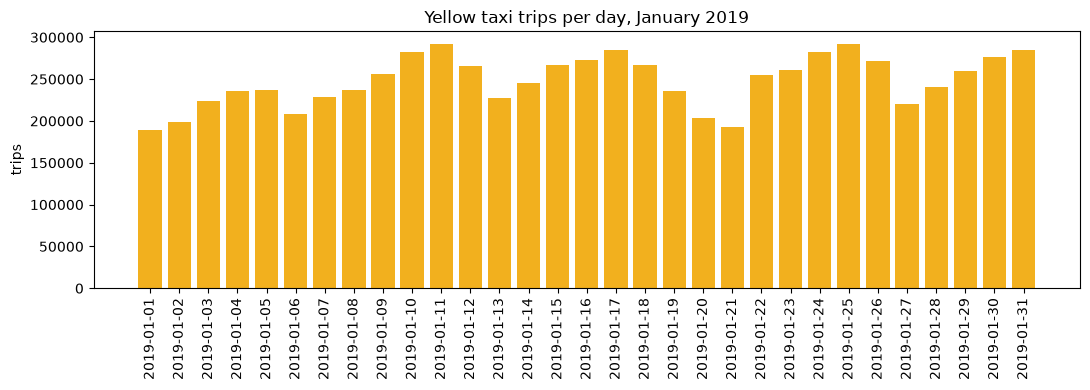

In [31]:
# Visualization 1: trips per day
pdf = daily.orderBy("day").toPandas()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(pdf["day"].astype(str), pdf["count"], color="#f2b01e")
ax.set_title("Yellow taxi trips per day, January 2019")
ax.set_ylabel("trips")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

**Chart 2 - trips per hour.** The chart shows the daily cycle: a minimum at 4 am, a fast increase between 5 and 8 am, a plateau during the morning and the biggest peak at 6 pm.

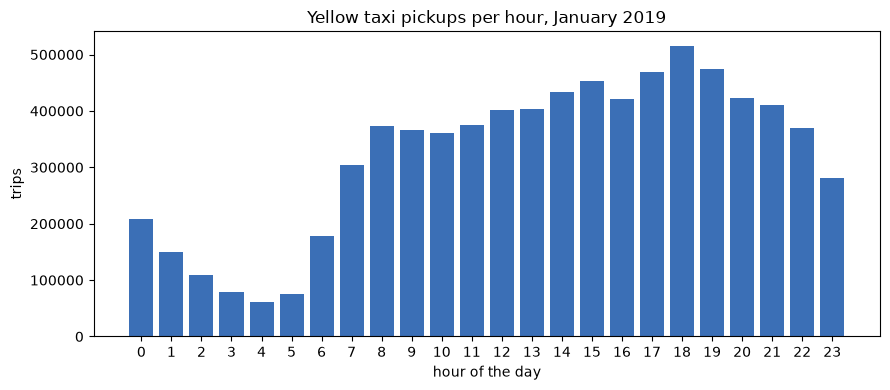

In [32]:
# Visualization 2: trips per hour of the day
pdf = hourly.toPandas()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(pdf["hour"], pdf["count"], color="#3b6fb6")
ax.set_title("Yellow taxi pickups per hour, January 2019")
ax.set_xlabel("hour of the day")
ax.set_ylabel("trips")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

**Chart 3 - pickups and fare by borough.** A logarithmic scale is needed for the pickups because Manhattan has about 15 times more trips than Queens and about 19,000 times more than Staten Island. The second chart shows that the fare is the opposite of the number of trips: Manhattan is the cheapest (10.63 dollars) and the boroughs with few pickups are the most expensive (EWR 78.26 dollars, Staten Island 44.68 dollars, Queens 35.71 dollars) because those trips are long.

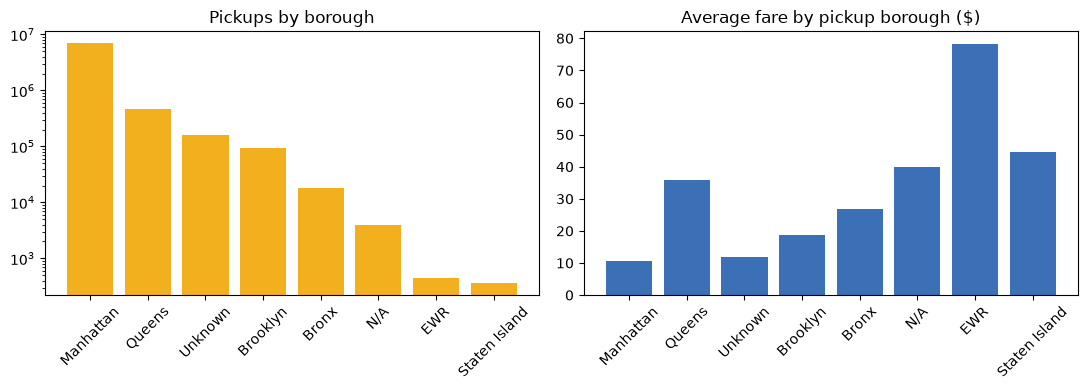

In [33]:
# Visualization 3: pickups and average fare by borough
pdf = (pickups.join(
           valid.groupBy("pickup_borough")
                .agg(F.avg("fare_amount").alias("avg_fare")), "pickup_borough")
       .orderBy(F.desc("pickups")).toPandas())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(pdf["pickup_borough"], pdf["pickups"], color="#f2b01e")
axes[0].set_title("Pickups by borough")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(pdf["pickup_borough"], pdf["avg_fare"], color="#3b6fb6")
axes[1].set_title("Average fare by pickup borough ($)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Summary

- The January 2019 file is dirty: dates from 2001 to 2088, negative fares, fares of several hundred thousand dollars, trips of 30 days. Cleaning is required before any average.
- Taxi demand follows a clear rhythm: peak on Thursday-Friday evenings (6 pm), low on Sundays, at 4 am and on holidays.
- 90% of the pickups are in Manhattan, where trips are short and cheap; trips leaving Manhattan for Queens, Staten Island or Newark are long and expensive.
- The tip depends on the fare (and so the distance) but not on the number of passengers.
- Between January 2019 and January 2025 the number of trips dropped by 55% while the average fare rose by 46%.
- Not done from the "where to go from here" section: the full year 2019 and the seasons.